# GANs

In this seminar, we will see how to implement a Generative Adversarial Network.

For simplicity, we will work with [MNIST](http://yann.lecun.com/exdb/mnist/) that we have already seen at Week 02.

Let's do some imports and load the dataset + create the dataloader.

In [ ]:
# Some imports

# computation stuff
import torch
import numpy as np

# plotting stuff
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina' # makes the quality higher

import seaborn as sns
sns.set_style("whitegrid") # improves the quality of matplotlib images and adds grid

In [ ]:
import torchvision

transform = torchvision.transforms.Compose( # Sequential application of transforms, for this example it is unnecessarily
    [
        torchvision.transforms.ToTensor(), # from Image class to Tensor
        torchvision.transforms.Normalize((0.5,), (0.5,))
    ]
)

mnist_train = torchvision.datasets.MNIST(
    "./mnist/", train=True, download=True, transform=transform
)
mnist_val = torchvision.datasets.MNIST(
    "./mnist/", train=False, download=True, transform=transform
)

torch.Size([1, 28, 28])


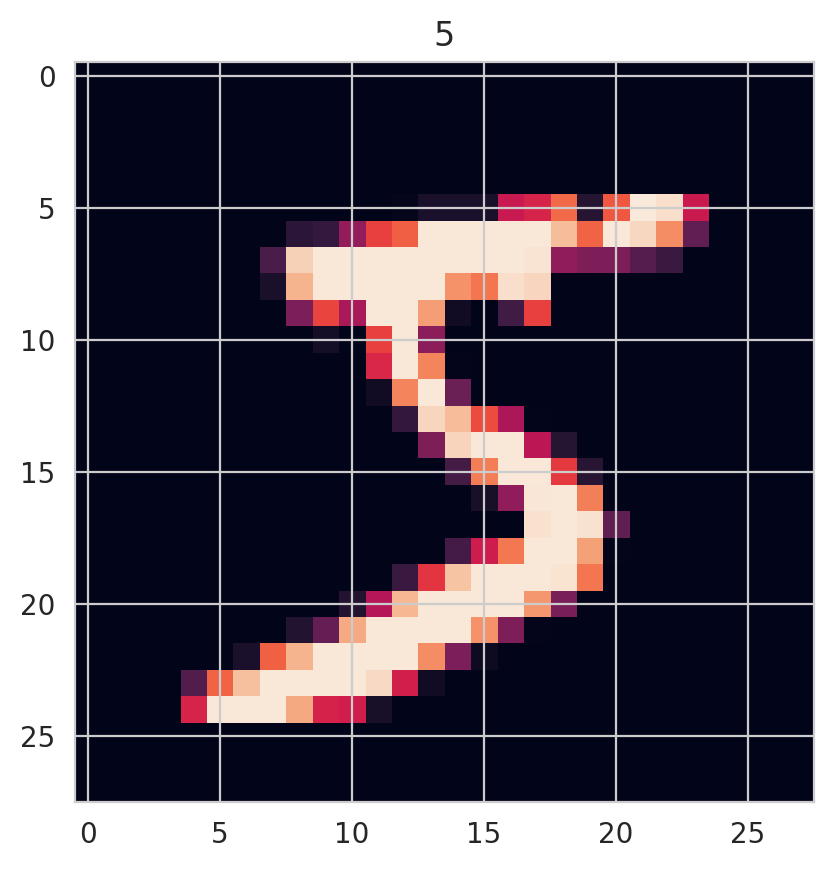

In [ ]:
example_img, example_label = mnist_train[0]
print(example_img.shape) # C x H x W, 1 channel -- grayscale image
plt.imshow(example_img[0])
plt.title(example_label)
plt.show()

In [ ]:
train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mnist_val, batch_size=64, shuffle=False)

## GAN Model

As in the [original](https://arxiv.org/abs/1406.2661) GAN model, we will use fully-connected networks. Note that, in general, any architecture can be used here, as long as the output is of the desired shape.

Our pipeline is as follows:

$$
z \sim \mathcal{N}(0,I), z \in \mathbf{R}^{k} \text{ is given to $G$ to generate image } \hat{x} = G(z)
$$

We add a Discriminator $D$ to distinguish between $x \sim p_{\text{data}}$ and $\hat{x} \sim p_{G}$ (classification task).

The final loss is:

$$
\min_{G}\max_{D} \mathbf{E}_{x \sim p_{\text{data}}} \log D(x) + \mathbf{E}_{z\sim p_z} \log (1 - D(G(z)))
$$



In [ ]:
import torch
import torch.nn as nn


class Generator(nn.Module):
    def __init__(self, z_dim=100, img_dim=28*28):
        super().__init__()
        self.z_dim = z_dim
        self.img_dim = img_dim

        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, img_dim),
            nn.Tanh() # to ensure the output is in [-1, 1]
        )

    def forward(self, z):
        x = self.net(z)
        x = x.view(z.size(0), 1, 28, 28)
        return x


class Discriminator(nn.Module):
    def __init__(self, img_dim=28*28):
        super().__init__()
        self.img_dim = img_dim

        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid() # to ensure the output is in [0,1]. Not needed if we use BCEWithLogitsLoss, but needed for BCELoss
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

### GAN Training

$$
\min_{G}\max_{D} \mathbf{E}_{x \sim p_{\text{data}}} \log D(x) + \mathbf{E}_{z\sim p_z} \log (1 - D(G(z)))
$$

We will do it in 2 steps. First, update D, then update G.

D-update:
$$
\max_{D} \mathbf{E}_{x \sim p_{\text{data}}} \log D(x) + \mathbf{E}_{z\sim p_z} \log (1 - D(G(z)))
$$

G-update:
$$
\min_{G} \mathbf{E}_{z\sim p_z} \log (1 - D(G(z)))
$$

For stability, we instead use **non-saturating** version:
$$
\min_{G} -\mathbf{E}_{z\sim p_z} \log (D(G(z)))
$$

This is Cross-Entropy. Since we have only single scalar as an output, we use `BCE` (Binary Cross Entropy) criterion from `PyTorch`.

In [ ]:
criterion = torch.nn.BCELoss()

For the evaluation, we need to somehow compare $p_{G}$ and $p_{\text{data}}$ on unseen real data. One way of doing so is to sample a lot of $G$ images and a lot of real images. Then, pass them through a pretrained backbone to get some latent representtions and compute some statistics on these representations.

**Fréchet Inception Distance (FID)** measures the distance between real and generated image distributions in a feature space.

Let $\phi(x)$ be features extracted from a pretrained backbone (pretrained on large-scale image classifiaiton datasets).

Given real samples $\{x_i\}$ and generated samples $\{\tilde{x}_i\}$:

$$
f_i = \phi(x_i), \quad \tilde{f}_i = \phi(\tilde{x}_i)
$$

Estimate Gaussian statistics:
$$
\mu_r = \mathbb{E}[f], \quad \Sigma_r = \mathrm{Cov}(f)
$$
$$
\mu_g = \mathbb{E}[\tilde{f}], \quad \Sigma_g = \mathrm{Cov}(\tilde{f})
$$

FID:
$$
\mathrm{FID} = \|\mu_r - \mu_g\|^2 + \mathrm{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)
$$

Interpretation:
- $\|\mu_r - \mu_g\|^2$ → shift in feature means (content mismatch)
- $\mathrm{Tr}(\cdot)$ → mismatch in covariance (diversity/structure)

Lower is better: $\mathrm{FID} = 0 \iff \mu_r=\mu_g,\ \Sigma_r=\Sigma_g$.

We assume Gaussian distributions for tractability and stability, not because features are truly Gaussian.

Given features $f = \phi(x) \in \mathbb{R}^d$, the true distribution $p(f)$ is unknown and complex.  
Instead, we approximate it with a Gaussian using only first and second moments:

$$
p(f) \approx \mathcal{N}(\mu, \Sigma), \quad
\mu = \mathbb{E}[f], \ \Sigma = \mathrm{Cov}(f)
$$

This leads to a closed-form distance (2-Wasserstein / Fréchet distance) between Gaussians:

$$
W_2^2(\mathcal{N}_r, \mathcal{N}_g)
= \|\mu_r - \mu_g\|^2
+ \mathrm{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)
$$

Why this approximation is used:

- **Closed form**: avoids density estimation in high dimension ($d=2048$)
- **Low sample complexity**: estimating $\mu,\Sigma$ is reliable with finite data
- **Second-order statistics**: captures mean (content) + covariance (diversity)

Intuition:
$$
\text{match } p_r(f) \approx p_g(f)
\;\Rightarrow\;
\text{match } (\mu_r, \Sigma_r) \approx (\mu_g, \Sigma_g)
$$

Limitations:
- Ignores higher-order moments
- Real feature distributions are not Gaussian
- Different distributions can share the same $(\mu, \Sigma)$

In [ ]:
!pip install torchmetrics[image]

In [ ]:
from IPython import display
from tqdm.auto import tqdm

from torchmetrics.image.fid import FrechetInceptionDistance


def show_generated_images(generator, z_dim, device, n_images=16):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_images, z_dim, device=device)
        fake_images = generator(z).cpu()

    # from [-1, 1] to [0, 1]
    fake_images = (fake_images + 1) / 2

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, img in zip(axes.flatten(), fake_images):
        ax.imshow(img[0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def prepare_for_fid(images):
    """
    images: tensor of shape [B, 1, H, W], assumed to be in [-1, 1]
    returns: uint8 tensor of shape [B, 3, H, W] in [0, 255]
    """
    images = (images + 1) / 2          # [-1,1] -> [0,1]
    images = images.clamp(0, 1)
    images = images.repeat(1, 3, 1, 1) # grayscale -> RGB
    images = (images * 255).to(torch.uint8)
    return images


def compute_fid(generator, val_dataloader, z_dim, device, max_real=None):
    generator.eval()

    fid = FrechetInceptionDistance(feature=2048).to(device)

    n_real = 0

    with torch.no_grad():
        for real_images, _ in val_dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # real
            real_for_fid = prepare_for_fid(real_images)
            fid.update(real_for_fid, real=True)

            # fake
            z = torch.randn(batch_size, z_dim, device=device)
            fake_images = generator(z)
            fake_for_fid = prepare_for_fid(fake_images)
            fid.update(fake_for_fid, real=False)

            n_real += batch_size
            if max_real is not None and n_real >= max_real:
                break

    score = fid.compute().item()
    return score


def train_one_epoch_gan(
    generator,
    discriminator,
    dataloader,
    criterion,
    g_optimizer,
    d_optimizer,
    device,
    z_dim
):
    generator.train()
    discriminator.train()

    avg_g_loss = 0.0
    avg_d_loss = 0.0

    for batch_idx, (real_images, _) in tqdm(enumerate(dataloader), total=len(dataloader)):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # =========================
        # 1) Train Discriminator
        # =========================
        z = torch.randn(batch_size, z_dim, device=device)
        fake_images = generator(z)

        real_preds = discriminator(real_images)
        fake_preds = discriminator(fake_images.detach())

        d_real_loss = criterion(real_preds, real_labels)
        d_fake_loss = criterion(fake_preds, fake_labels)
        d_loss = 0.5 * (d_real_loss + d_fake_loss)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # =========================
        # 2) Train Generator
        # =========================
        z = torch.randn(batch_size, z_dim, device=device)
        fake_images = generator(z)
        fake_preds = discriminator(fake_images)

        # non-saturating generator loss
        g_loss = criterion(fake_preds, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        avg_d_loss += d_loss.item()
        avg_g_loss += g_loss.item()

    avg_d_loss /= (batch_idx + 1)
    avg_g_loss /= (batch_idx + 1)

    return avg_g_loss, avg_d_loss


def train_gan(
    generator,
    discriminator,
    train_dataloader,
    val_dataloader,
    criterion,
    g_optimizer,
    d_optimizer,
    device,
    z_dim=100,
    n_epochs=20,
    fid_every=1,
    fid_max_real=2000,
):
    g_losses = []
    d_losses = []
    fid_scores = []

    for epoch in range(n_epochs):
        avg_g_loss, avg_d_loss = train_one_epoch_gan(
            generator=generator,
            discriminator=discriminator,
            dataloader=train_dataloader,
            criterion=criterion,
            g_optimizer=g_optimizer,
            d_optimizer=d_optimizer,
            device=device,
            z_dim=z_dim
        )

        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)

        fid_value = None
        if (epoch + 1) % fid_every == 0:
            fid_value = compute_fid(
                generator=generator,
                val_dataloader=val_dataloader,
                z_dim=z_dim,
                device=device,
                max_real=fid_max_real,
            )
            fid_scores.append((epoch + 1, fid_value))

        display.clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(g_losses, label="Generator loss")
        axes[0].plot(d_losses, label="Discriminator loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].set_title("GAN training losses")
        axes[0].legend()

        if fid_scores:
            fid_epochs, fid_vals = zip(*fid_scores)
            axes[1].plot(fid_epochs, fid_vals, marker="o", label="FID")
            axes[1].set_xlabel("Epoch")
            axes[1].set_ylabel("FID")
            axes[1].set_title("Validation FID")
            axes[1].legend()
        else:
            axes[1].axis("off")

        plt.tight_layout()
        plt.show()

        show_generated_images(generator, z_dim=z_dim, device=device, n_images=16)

        msg = (
            f"Epoch [{epoch+1}/{n_epochs}] | "
            f"G loss: {avg_g_loss:.4f} | "
            f"D loss: {avg_d_loss:.4f}"
        )
        if fid_value is not None:
            msg += f" | FID: {fid_value:.4f}"
        print(msg)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

z_dim = 100
G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)


g_optimizer = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

Note that we changed $\beta_1$ in Adam! This is the momentum coefficient: at each step $t$, we calculate the new candidate gradient $g'_t$ and define $g = \beta_1 g_{t-1} + (1 - \beta_1) g'_t$.

But GANs objective depends on both $D$ and $G$ and always changes. Old gradients may become irrelative very fast and destabilize the training.

The default value is $0.9$, which is too high.

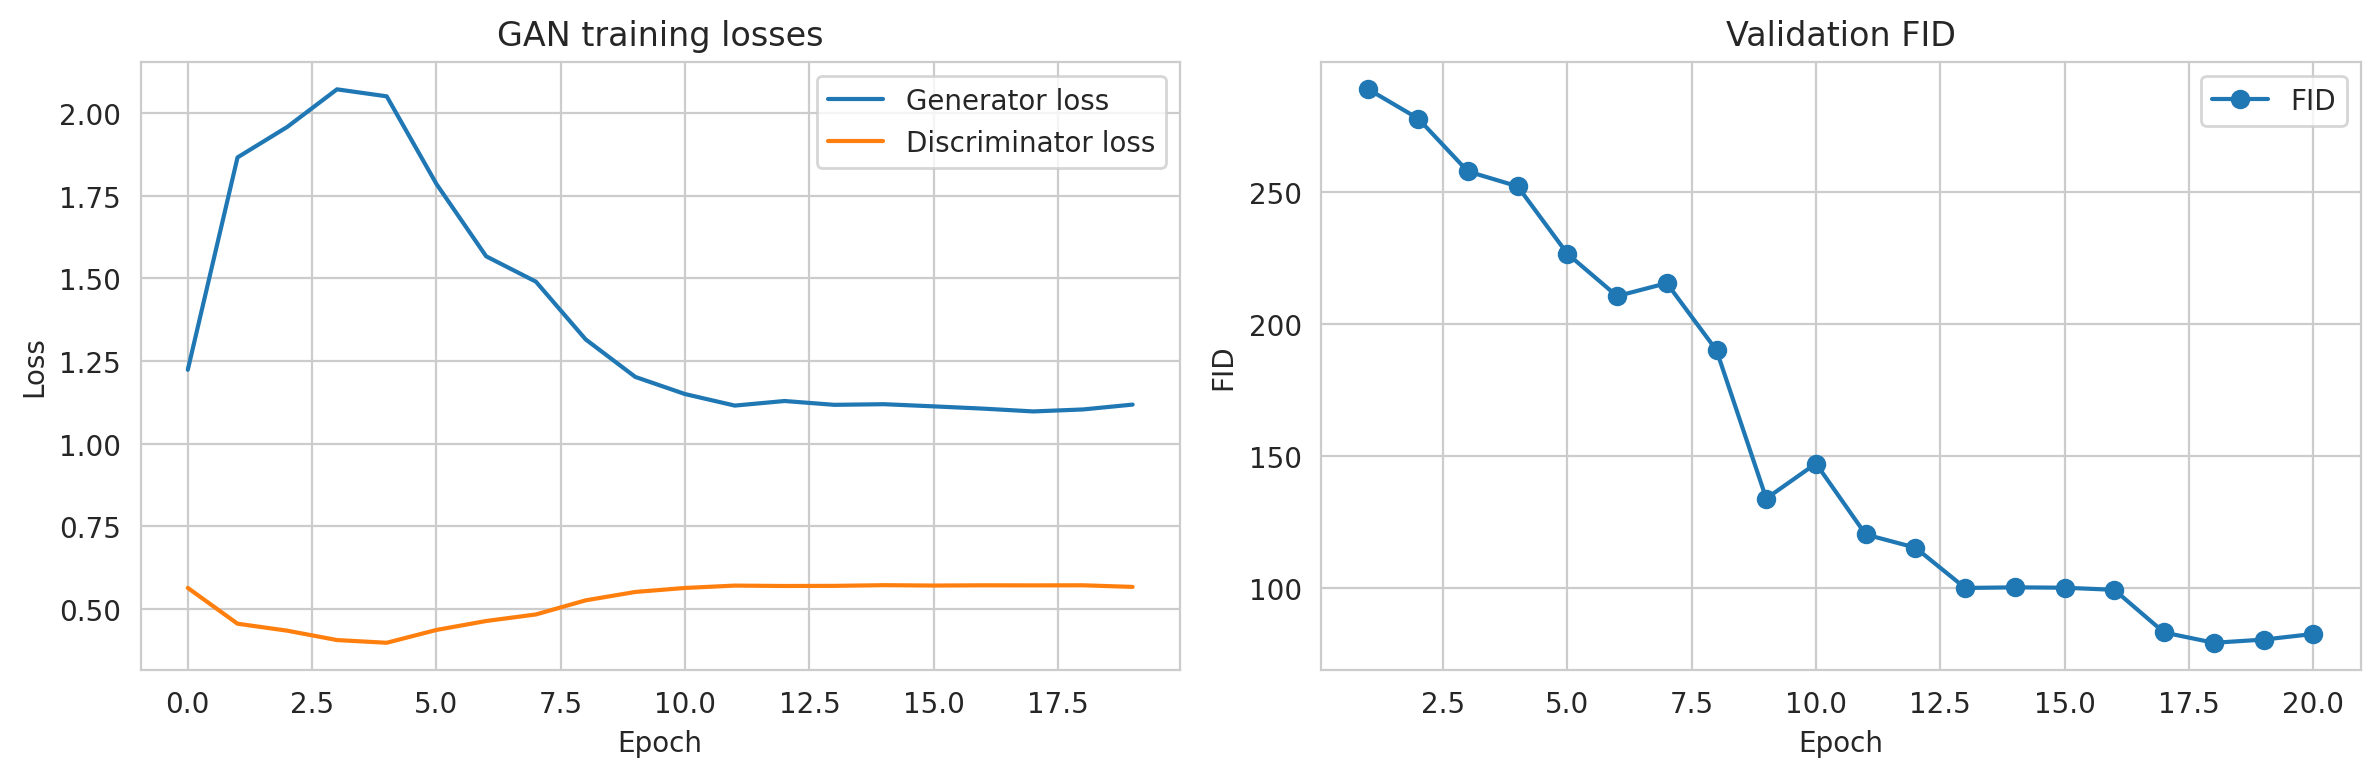

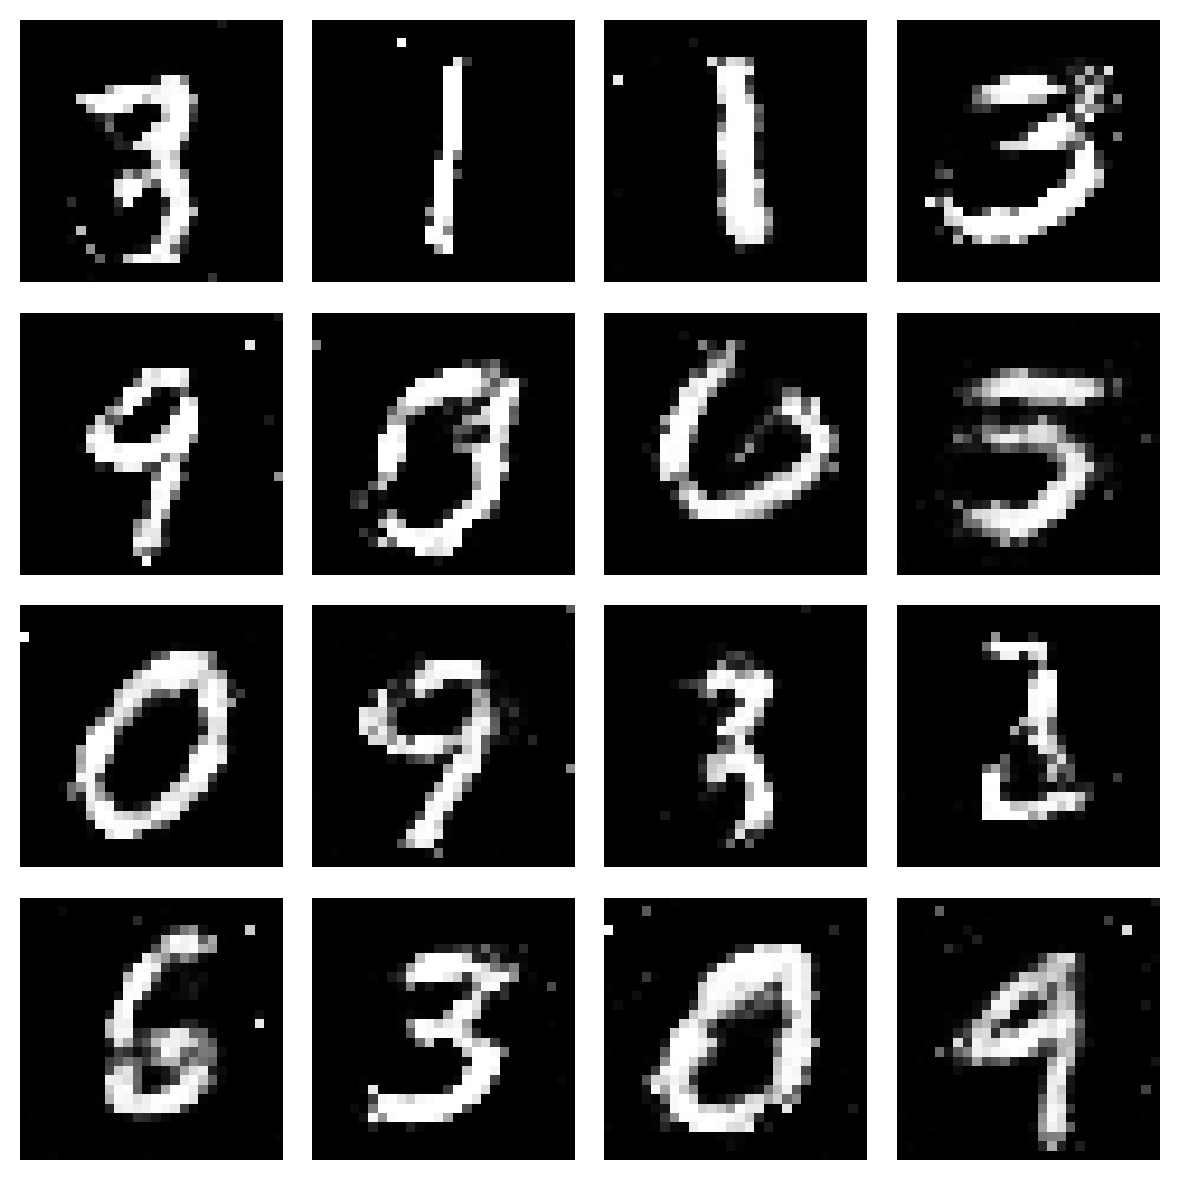

Epoch [20/20] | G loss: 1.1183 | D loss: 0.5669 | FID: 82.7503


In [ ]:
train_gan(
    generator=G,
    discriminator=D,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    criterion=criterion,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    device=device,
    z_dim=z_dim,
    n_epochs=20,
    fid_every=1,
    fid_max_real=2000,
)